In [4]:
#   libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier


from sklearn.metrics import r2_score, accuracy_score, confusion_matrix

from sklearn.cluster import KMeans

In [5]:
# Load Dataset

df = pd.read_csv("StudentPerformanceFactors.csv")

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [6]:
# Using Hours_Studied to predict Exam_Score

X = df[['Hours_Studied']]
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

model = LinearRegression()
model.fit(X_train, y_train)

# Results

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.1995531443217341


In [7]:
X = df[['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']]
X = pd.concat([X, pd.get_dummies(df['Motivation_Level'], prefix='Motivation_Level')], axis=1)
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluate
print("R2 Score (Multiple):", r2_score(y_test, y_pred))

R2 Score (Multiple): 0.5875760903312952


In [9]:
# Convert Exam Score into categories (Low, Medium, High)

df['Score_Category'] = pd.cut(df['Exam_Score'],
                             bins=[0, 50, 75, 100],
                             labels=['Low', 'Medium', 'High'])

In [10]:
# Select data

X_features = df[['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']]
X_motivation = pd.get_dummies(df['Motivation_Level'], prefix='Motivation_Level')

X_combined = pd.concat([X_features, X_motivation], axis=1)
y = df['Score_Category']

# Combine X and y, then drop rows with any NaN values
combined_df = pd.concat([X_combined, y], axis=1)
combined_df.dropna(inplace=True) # Drop rows if any column has NaN

X = combined_df.drop('Score_Category', axis=1)
y = combined_df['Score_Category']

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [17]:
# Train Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = log_model.predict(X_test)
print("Logistic Accuracy:", accuracy_score(y_test, y_pred))

Logistic Accuracy: 0.8526645768025078


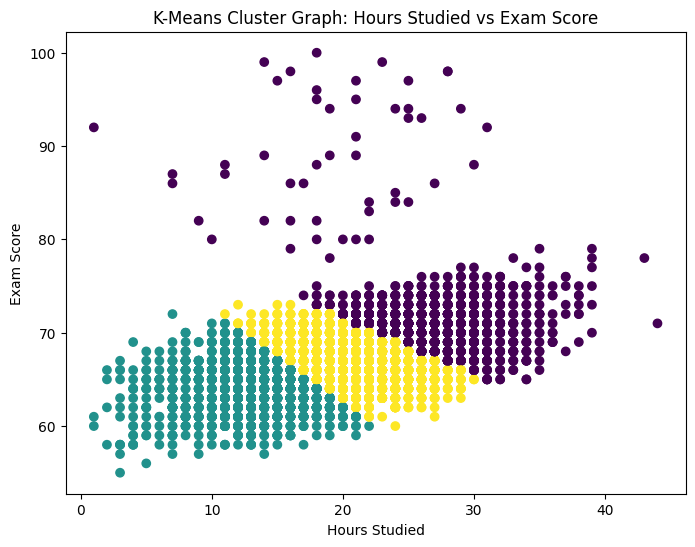

         Hours_Studied  Exam_Score
Cluster                           
0            26.711551   71.473267
1            13.312190   63.972973
2            20.591669   67.093473


In [16]:
# Cluster Graph using K-Means

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select two variables for easy visual explanation
cluster_data = df[['Hours_Studied', 'Exam_Score']]

# Scale the data
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

# Create 3 clusters
kmeans = KMeans(n_clusters=3, random_state=1, n_init=10)
df['Cluster'] = kmeans.fit_predict(cluster_scaled)

# Draw cluster graph
plt.figure(figsize=(8, 6))
plt.scatter(
    df['Hours_Studied'],
    df['Exam_Score'],
    c=df['Cluster']
)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("K-Means Cluster Graph: Hours Studied vs Exam Score")
plt.show()

# Show average values for each cluster
cluster_summary = df.groupby('Cluster')[['Hours_Studied', 'Exam_Score']].mean()
print(cluster_summary)

In [ ]:
# Train Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predict and evaluate
y_pred = nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred))

Naive Bayes Accuracy: 0.9886535552193646


/tmp/ipykernel_350/3887011649.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Performance_Level'] = pd.cut(


Decision Tree Accuracy: 0.804858934169279


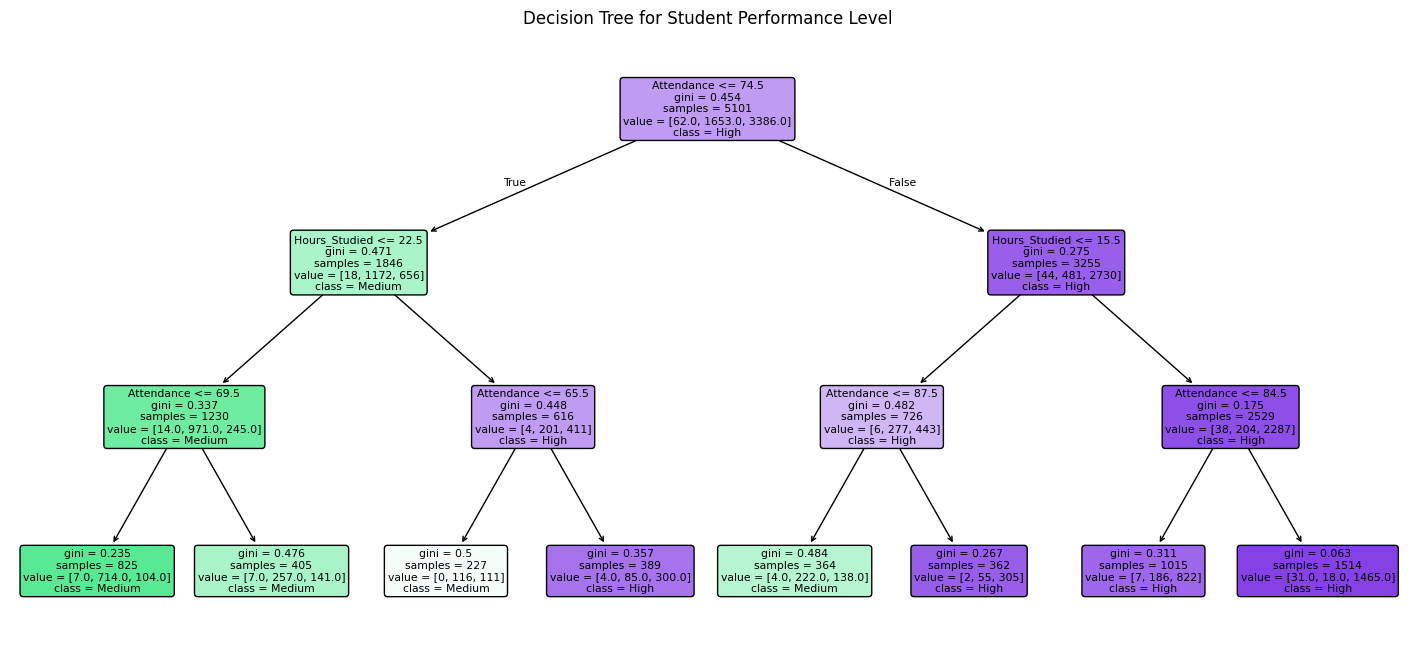

In [15]:
# Decision Tree Graph

df = df.dropna()

# Create performance categories from Exam_Score
df['Performance_Level'] = pd.cut(
    df['Exam_Score'],
    bins=[0, 65, 75, 100],
    labels=['Low', 'Medium', 'High']
)

# Select simple features that are easy to explain
X = df[['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']]
y = df['Performance_Level']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# Train decision tree
tree_model = DecisionTreeClassifier(max_depth=3, random_state=1)
tree_model.fit(X_train, y_train)

# Predict and check accuracy
y_pred = tree_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))

# Draw tree graph
plt.figure(figsize=(18, 8))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=['Low', 'Medium', 'High'],
    filled=True,
    rounded=True
)
plt.title("Decision Tree for Student Performance Level")
plt.show()

In [ ]:
# Select features for clustering
X = df[['Hours_Studied', 'Attendance', 'Exam_Score']]

# Apply K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=1)

# Assign cluster labels
df['Cluster'] = kmeans.fit_predict(X)

# Show results
df[['Hours_Studied', 'Attendance', 'Exam_Score', 'Cluster']].head()

,Hours_Studied,Attendance,Exam_Score,Cluster
0,23,84,67,0
1,19,64,61,1
2,24,98,74,2
3,29,89,71,2
4,19,92,70,2
